In [71]:
from IPython.display import clear_output
import numpy as np
np.set_printoptions(linewidth=10000)
import matplotlib.pyplot as plt
import time
def ttic():
    return time.time()

def ttoc(tic):
    return time.time() - tic

from importnb import Notebook

with Notebook():
    import lipm
    from zmp_ref import zmp_ref

## Solve the QP
We end up with an equality-constrained QP:

$\min_{\mathbf{x}, \mathbf{u}} \frac{1}{2}\begin{bmatrix}\mathbf{x}^T & \mathbf{u}^T \end{bmatrix}^T \mathbf{H}\begin{bmatrix}\mathbf{x} \\ \mathbf{u} \end{bmatrix} + \mathbf{g}^T\begin{bmatrix}\mathbf{x} \\ \mathbf{u} \end{bmatrix}$

$s.t. \mathbf{E}\begin{bmatrix}\mathbf{x} \\ \mathbf{u} \end{bmatrix} = \mathbf{e}$

that can be solved building the KKT linear system:

$\begin{bmatrix}\mathbf{H} & \mathbf{E}^T \\ \mathbf{E} & \mathbf{0}\end{bmatrix} \begin{bmatrix}\mathbf{x} \\ \mathbf{u} \\ \boldsymbol{\lambda} \end{bmatrix} = \begin{bmatrix}-\mathbf{g} \\ \mathbf{e} \end{bmatrix}$

In [72]:
def calcKKT(H, E):
    # Build the KKT system (this step can be performed only once since the system does not change!)
    KKT = np.zeros((H.shape[0] + E.shape[0], H.shape[0] + E.shape[0]))
    KKT[:H.shape[0], :H.shape[0]] = H
    KKT[:H.shape[0], H.shape[0]:] = E.T
    KKT[H.shape[0]:, :H.shape[0]] = E
    return KKT

def solveQP(H, grad, E, e):
    KKT = calcKKT(H, E)
    rhs = np.concatenate([-grad, e]) # This can change during execution!

    # Solve the KKT system
    return np.linalg.solve(KKT, rhs)

## Solve the Trajectory Optimization Problem
We first solve the Trajectory Optimization (TO) problem, which can be useful to check the correctness of the code.
As a TO problem, we assign the ZMP references and compute the solution.
Notice that due to linearity the QP is solved in a single step.

In [73]:
# Assign reference for ZMP
for j in range(lipm.ns):
         lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_ref(lipm.ns)[:, j].flatten())

In [74]:
# Solve the QP
tic = ttic()
y = solveQP(lipm.H, lipm.grad, lipm.E, lipm.e)
print(f"solved in: {ttoc(tic)} seconds")

solved in: 0.13047027587890625 seconds


In [75]:
# Extract state trajectories
x = np.zeros((lipm.ns + 1) * lipm.nx)
for i in range(lipm.ns):
    x[i * lipm.nx:(i + 1) * lipm.nx] = y[i * (lipm.nx + lipm.nu):i * (lipm.nx + lipm.nu) + lipm.nx].flatten()
# Fill last state
x[lipm.ns * lipm.nx:(lipm.ns + 1) * lipm.nx] = y[lipm.ns * (lipm.nx + lipm.nu):lipm.ns * (lipm.nx + lipm.nu) + lipm.nx].flatten()

# Extract control trajectories
u = np.zeros((lipm.nu, lipm.ns))
for i in range(lipm.ns):
    # The control vector u is after the state x in y:
    start_idx = i * (lipm.nx + lipm.nu) + lipm.nx
    end_idx = start_idx + lipm.nu
    u[:, i] = y[start_idx:end_idx].flatten()

In [76]:
# Extract r and rdot
r = np.zeros((2, lipm.ns + 1))
rdot = np.zeros((2, lipm.ns + 1))
for i in range(lipm.ns + 1):
    r[:, i] = x[i * lipm.nx:i * lipm.nx + 2].flatten()
    rdot[:, i] = x[i * lipm.nx + 2:i * lipm.nx + 4].flatten()

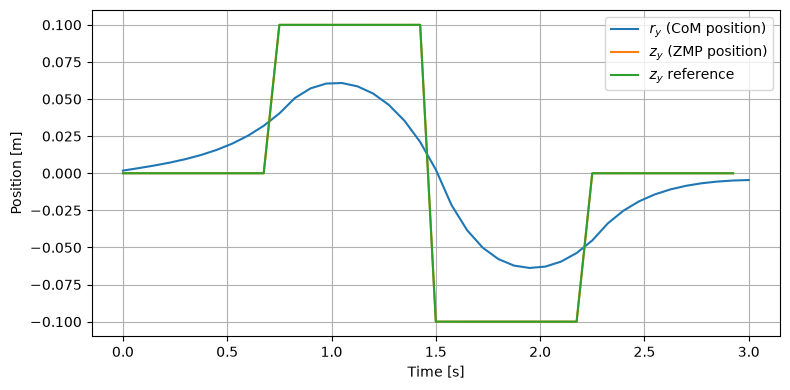

In [77]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(np.arange(lipm.ns + 1) * lipm.dt, r[1, :], label='$r_y$ (CoM position)')
plt.plot(np.arange(lipm.ns) * lipm.dt, u[1,:], label='$z_y$ (ZMP position)')
plt.plot(np.arange(lipm.ns) * lipm.dt, zmp_ref(lipm.ns)[1,:], label='$z_y$ reference')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Notice that to move the CoM up (left) the ZMP moves instantaneously down (right) and consecutively track closely the reference.

## Model Predictive Control
To solve the Model Predictive Control (MPC) problem, we solve the QP in a loop. At each iteration, we assign a new initial state and reference to the problem.

In this example, we compute the next state simply by applying the control to the actual state (this corresponds to using the second state $\mathbf{x}_1$ computed by the QP).

For assigning the reference, we consider the reference starting from the end and moving toward the initial state (receding horizon).

In [56]:
# Zero all references
for i in range(lipm.ns):
    lipm.grad[i * (lipm.nx + lipm.nu):(i + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, np.zeros((2,1)).flatten())

In [57]:
# Simulation parameters
T = 4 * lipm.ns # Simulation time

In [58]:
x = np.zeros((lipm.nx, lipm.ns)) # Collect states
u = np.zeros((lipm.nu, lipm.ns)) # Collect controls

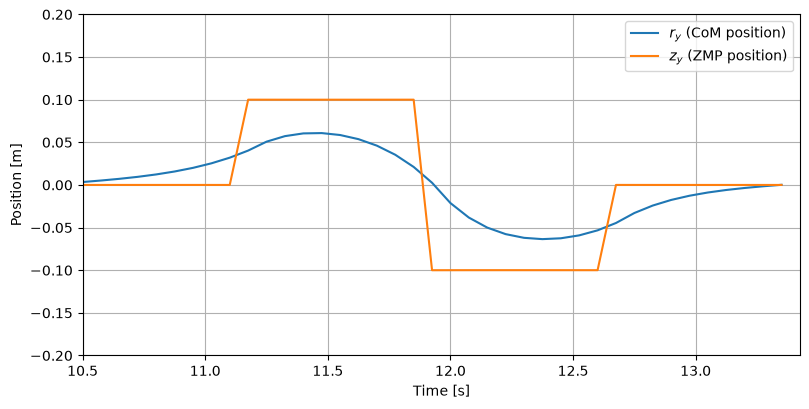

Average solution time is: 0.021220183372497557 seconds


In [59]:
x0 = np.zeros((lipm.nx, 1))
zmp_r = zmp_ref(lipm.ns)  # Future ZMP references
zmp_d = np.zeros(zmp_r.shape)

# --- Prepare plot ---
plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot(np.arange(lipm.ns) * lipm.dt, zmp_d[1, :], 'b-', label='$z_d$ (zmp desired)')
ax.set_xlim(0, lipm.ns * lipm.dt)
ax.set_xlabel('Time [s]')
ax.set_ylabel('ZMP [m]')
ax.set_title('ZMP Desired Over Time')
ax.legend()
fig.tight_layout()

scroll = 0
t = 0
# --- Main Loop ---
for i in range(T):
    x[:, i%lipm.ns] = x0.flatten()
    
    # We set the initial value constraint to the new initial value (in the real robot this is measured!)
    lipm.e[-lipm.nx:] = x0

    # Shift reference to the left
    for j in range(1, lipm.ns):
        zmp_d[:, j-1] = zmp_d[:, j]
    # Copy the new reference at the end of the horizon
    zmp_d[:, lipm.ns-1] = zmp_r[:, i % lipm.ns]
    
    # Compute gradient (assign reference to the problem)
    for j in range(lipm.ns):
        lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_d[:, j])

    # Solve the QP
    tic = ttic()
    y = solveQP(lipm.H, lipm.grad, lipm.E, lipm.e)
    t += ttoc(tic)

    # Retrieve computed control
    u0 = y[lipm.nx:lipm.nx + lipm.nu]

    # Compute new state integrating
    x1 = x0 + lipm.dt * (lipm.A @ x0 + lipm.B @ u0)

    # New state is new initial state
    x0 = x1

    u[:, i%lipm.ns] = u0.flatten()

    # --- Update Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    if i >= lipm.ns/2:
        scroll = scroll + 1
    
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, x[1, 0:i%lipm.ns], label='$r_y$ (CoM position)')
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, u[1, 0:i%lipm.ns], label='$z_y$ (ZMP position)')
    plt.ylim(-0.2, 0.2)
    plt.xlim(0 + scroll*lipm.dt, (i%lipm.ns+scroll)*lipm.dt)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.xlabel('Time [s]')
    plt.ylabel('Position [m]')
    plt.show()

# Keep the final plot open
plt.ioff()
plt.show()

print(f"Average solution time is: {t/T} seconds")

## Some Optimization
It is worth noting that, during the control loop, the only parts that change are the gradient and constraint values (Linear Time-Invariant system). This means that we do not need to compute the Hessian, the constraint matrix, and consequently the KKT matrix and its inversion at every control loop.

In [44]:
KKT = calcKKT(lipm.H, lipm.E)
tic = ttic()
iKKT = np.linalg.pinv(KKT)
print(f"solved in: {ttoc(tic)} seconds")

solved in: 0.08692002296447754 seconds


solved in: 0.00024080276489257812 seconds


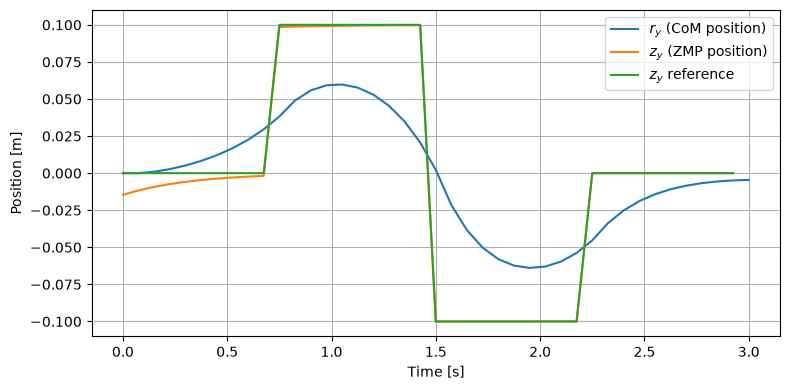

In [45]:
## Trajectory Optimization

# Assign reference for zmp
for j in range(lipm.ns):
         lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_ref(lipm.ns)[:, j].flatten())

# Initial state
lipm.e[-lipm.nx:] = np.zeros((lipm.nx,1))

rhs = np.concatenate([-lipm.grad, lipm.e])

tic = ttic()
y = iKKT@rhs
print(f"solved in: {ttoc(tic)} seconds")

# Extract state trajectories
x = np.zeros((lipm.ns + 1) * lipm.nx)
for i in range(lipm.ns):
    x[i * lipm.nx:(i + 1) * lipm.nx] = y[i * (lipm.nx + lipm.nu):i * (lipm.nx + lipm.nu) + lipm.nx].flatten()
# Fill last state
x[lipm.ns * lipm.nx:(lipm.ns + 1) * lipm.nx] = y[lipm.ns * (lipm.nx + lipm.nu):lipm.ns * (lipm.nx + lipm.nu) + lipm.nx].flatten()

# Extract control trajectories
u = np.zeros((lipm.nu, lipm.ns))
for i in range(lipm.ns):
    # The control vector u is after the state x in y:
    start_idx = i * (lipm.nx + lipm.nu) + lipm.nx
    end_idx = start_idx + lipm.nu
    u[:, i] = y[start_idx:end_idx].flatten()

# Extract r and rdot
r = np.zeros((2, lipm.ns + 1))
rdot = np.zeros((2, lipm.ns + 1))
for i in range(lipm.ns + 1):
    r[:, i] = x[i * lipm.nx:i * lipm.nx + 2].flatten()
    rdot[:, i] = x[i * lipm.nx + 2:i * lipm.nx + 4].flatten()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(np.arange(lipm.ns + 1) * lipm.dt, r[1, :], label='$r_y$ (CoM position)')
plt.plot(np.arange(lipm.ns) * lipm.dt, u[1,:], label='$z_y$ (ZMP position)')
plt.plot(np.arange(lipm.ns) * lipm.dt, zmp_ref(lipm.ns)[1,:], label='$z_y$ reference')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

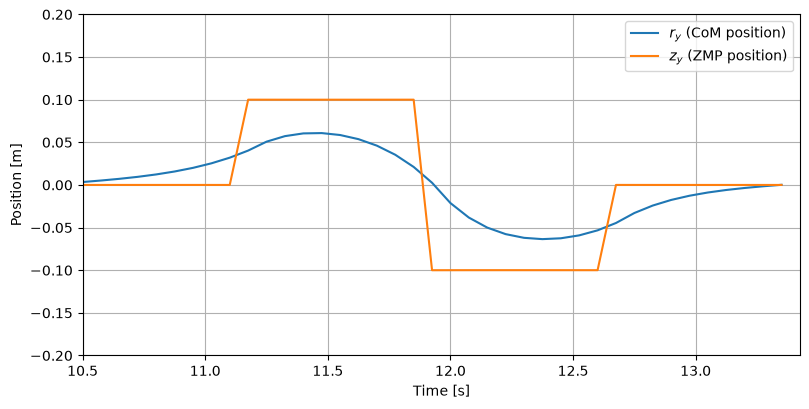

Average solution time is: 8.482486009597778e-05 seconds


In [47]:
## MPC

# Zero all references
for i in range(lipm.ns):
    lipm.grad[i * (lipm.nx + lipm.nu):(i + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, np.zeros((2,1)).flatten())

x = np.zeros((lipm.nx, lipm.ns)) # Collect states
u = np.zeros((lipm.nu, lipm.ns)) # Collect controls

x0 = np.zeros((lipm.nx, 1))
zmp_r = zmp_ref(lipm.ns)  # Future ZMP references
zmp_d = np.zeros(zmp_r.shape)

# --- Prepare Plot ---
plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot(np.arange(lipm.ns) * lipm.dt, zmp_d[1, :], 'b-', label='$z_d$ (zmp desired)')
ax.set_xlim(0, lipm.ns * lipm.dt)
ax.set_xlabel('Time [s]')
ax.set_ylabel('ZMP [m]')
ax.set_title('ZMP Desired Over Time')
ax.legend()
fig.tight_layout()

scroll = 0
# --- Main Loop ---
t = 0
for i in range(T):
    x[:, i%lipm.ns] = x0.flatten()

    lipm.e[-lipm.nx:] = x0

    # Shift reference
    for j in range(1, lipm.ns):
        zmp_d[:, j-1] = zmp_d[:, j]
    zmp_d[:, lipm.ns-1] = zmp_r[:, i % lipm.ns]
    
    # Compute gradient
    for j in range(lipm.ns):
        lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_d[:, j])

    # Solve the QP
    rhs = np.concatenate([-lipm.grad, lipm.e])
    tic = ttic()
    y = iKKT@rhs
    t += ttoc(tic)

    u0 = y[lipm.nx:lipm.nx + lipm.nu]
    x1 = x0 + lipm.dt * (lipm.A @ x0 + lipm.B @ u0)
    x0 = x1

    u[:, i%lipm.ns] = u0.flatten()

    # --- Update Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    if i >= lipm.ns/2:
        scroll = scroll + 1
    
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, x[1, 0:i%lipm.ns], label='$r_y$ (CoM position)')
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, u[1, 0:i%lipm.ns], label='$z_y$ (ZMP position)')
    plt.ylim(-0.2, 0.2)
    plt.xlim(0 + scroll*lipm.dt, (i%lipm.ns+scroll)*lipm.dt)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.xlabel('Time [s]')
    plt.ylabel('Position [m]')
    plt.show()

plt.ioff()
plt.show()

print(f"Average solution time is: {t/T} seconds")